# BME-336546-C08-Unsupervised learning - Dimensionality reduction (PCA)

## Dataset
   * ID number.
   * Diagnosis (M = malignant, B = benign).
   
Ten real-valued features are computed for each cell nucleus:

   * Radius (mean of distances from center to points on the perimeter) $[mm]$.
   * Texture (standard deviation of gray-scale values) $[N.U]$.
   * Perimeter $[mm]$.
   * Area $[mm^2]$.
   * Smoothness (local variation in radius lengths) $[mm]$.
   * Compactness (perimeter² / area — 1.0) $[N.U]$.
   * Concavity (severity of concave portions of the contour) $[N.U]$.
   * Concave points (number of concave portions of the contour) $[N.U]$.
   * Symmetry $[N.U]$
   * Fractal dimension (“coastline approximation” — 1) $[N.U]$.
    
The mean, standard error and “worst” or largest (mean of the three largest values) of these features were computed for each image, resulting in 30 features. For instance, field 3 of the table is the Mean Radius, 13 is the Radius SE and 23 is the Worst Radius.

## Main ML topic:
This tutorial will also deal with unsupervised learning. As we mentioned previously, we can find multiple uses in this field such as:
* Dimensionality reduction.
* Discovery of the data's structure (geometry of the data).
* Feature selection.
* Clustering.
* Visualization of high-dimensional data.
* Blind source separation (BSS).
* Data denoisng.
* Simulating data.

## Theory reminders
Many times, we encounter high-dimensional data that most of the "information" that it carries actually lies in a much lower dimensional space. For example, gray level images of the size $MXN$ have dimensionallity of $MN$ which can be very large even for relatively small images. However, if you take the image grid and randomize a number for every pixel, the chances to produce a meaningful image are almost 0. This implies that natural images of this size for instance, may "live" in another lower dimensional space. Just for vizualization, here is an example of $3D$ data that is actually embedded in a $2D$ space. 

<center><img src="images/2din3.png" width="550"><center>
<!-- ![image alt ><](/2din3.jpg) -->
<!-- <img src= <center>![2din3.png]</center> -->



### Curse of dimensionality
High dimensional datasets are at risk of being very sparse: most training instances are likely to be far away from each other.
Of course, this also means that a new instance will likely be far away from any training instance, making predictions much less reliable than in lower dimensions, since they will be based on much larger extrapolations.
In short, the more dimensions the training set has, the greater the risk of overfitting the model.
Therefore a dimension reduction method should sometime be applied.

Principle component analysis (PCA) is a linear unsupervised learning method mostly used for dimensionlaity reduction. It tries to find a linear surface (1D line, a plane or a hyper plane) where the data can be projected to and still maintain as much information as possible. Assuming $n$ samples of dimension $m$ that are stacked in the matrix $X \in \mathbb{R}^{mxn} $. Our goal is to acheive a matrix $Z \in \mathbb{R}^{kxn}$ where $k<<m$. In PCA, information is considered to be preserved where the variance of the projected data is maximal. In other words we are looking for a new **orthonormal** coordinates system composed of the columns of the matrix $U$. $$ \begin{equation}
U=\begin{pmatrix}
u_1| & u_2| & \dots|& u_k
\end{pmatrix} \in \mathbb{R}^{mxk}
\label{eq:U} \tag{1}
\end{equation} $$
Once we project our data on to the new subspace we get: $$ \begin{equation}
Z=U^TX \in \mathbb{R}^{kxn}
\label{eq:Z} \tag{2}
\end{equation} $$
The sampled covarince of the projected data is calculated as follows:$$ \begin{equation}
Cov(Z) = ZZ^T = U^TXX^TU = U^TCU\\
Var(Z) = trace(Cov(Z))
\label{eq:var_z} \tag{3}
\end{equation} $$
where $C$ is the sampled covariance matrix of **centered** $X$ and thus, $X$ should be centered prior to all other calculations. Practically it should also be scaled. Now, we can set a maximization problem of $U$ subject to a constraint: $$ \begin{equation}
\max_{U}\{trace(U^TCU)\} \space s.t. \space U^TU=I
\label{eq:optimization} \tag{4}
\end{equation} $$
It was shown in the lecture that the solution of this problem is the matrix of the first $k^{th}$ eigenvectors of $C$, ordered by their descending corresponding $k$ eigenvalues. The eigenvalues are the variences of the projected data along each corresponding axis. It is also equivalent to minimizing the $L_2$ norm of the sum of the orthogonal distances of the data points from the $i^{th}$ axis $(u_i)$ simply due to Pythagoras' theorem as shown heuristicaly in the following gifs. The varince is simply the sum of the distances of the green X's (the projections) on the rotating axis in the left gif.

<left><img src="images/min_max.gif" width="350"><left>
<right><img src="images/pca.gif" width="450"><right>
    
Notice that it is **not** the same as linear regression because in linear regression we try to minimize the $L_2$ norm of the residuals which are the "distances" that are orthogonal to the original axis and not to the new one ($u_i$) as shown below:
<center><img src="images/PCA_vs_linear_regression.png" width="400"><center>
    


Finally, it can also be thought as finding the principle axes of a fitted elipsoid. 

<center><img src="images/elipsoid.png" width="350"><center>

Now if we would like to have an approximation of $X$ by using the low dimensional space, all we have to do is simply calculate the linear combination of the $U$ basis. Fortunetly, Our basis is orthonormal, and thus the corresponding coefficient is simply the projections. $$ \begin{equation}
\tilde{X}=UZ\in \mathbb{R}^{mxn}\\
\label{eq:approx} \tag{5}
\end{equation} $$
The higher dimension you choose $(k)$, the more "information" or "energy" you gain but  less dimensionality reduction acheived. $$ \begin{equation}
\parallel \tilde{X}-X\parallel^2_2 \space \overset{k \rightarrow m}{\longrightarrow} \space \bar{0}
\label{eq:approx energy} \tag{6}
\end{equation} $$


One way of choosing  k is to calculate the ratio of the preserved energy as follows: $$ \begin{equation}
r=\frac{\lambda_1+\lambda_2+\dots +\lambda_k}{\lambda_1+\lambda_2+\dots +\lambda_k +\dots + \lambda_m}
\label{eq:energy} \tag{7}
\end{equation} $$
The $k$ that brings that ratio to be larger than 0.95 is considered to be well preserving and hopefully it still satisfies $k<<m$.


PCA has also its' nonlinear form which is similar to what we have seen in SVM. So we define a nonlinear function $\Phi(x)$ and our covariance matrix is now $C=\Phi(X)\Phi^T(X)$. Centering should be applied here as well and the kernel trick is also applicable.

## Data loading

In [1]:
import numpy as np
import itertools
from tqdm import tqdm
import pickle
import sys
import pandas as pd
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
mpl.style.use(['ggplot']) 
%matplotlib inline
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from IPython.display import display, clear_output
from sklearn.linear_model import LogisticRegression


from sklearn.datasets import fetch_lfw_people
# from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
# import scipy.io as sio

We will start by loading the data that we had in our fourth tutorial directly from `sklearn.datasets`.

In [2]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

This loading have some methods and attributes that are useful:

In [ ]:
data.keys()

In [ ]:
print(data['DESCR'])

In [ ]:
data['target']

In [3]:
df_feat = pd.DataFrame(data['data'],columns=data['feature_names'])
df_feat.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Let's begin with choosing three features **without scaling them**.

In [4]:
feat_name =['mean radius', 'mean concavity', 'mean symmetry']
X3d = df_feat[feat_name]
y = data['target']
X3d = X3d.values
X_train, X_test, y_train, y_test = train_test_split(X3d, y, test_size=0.1, stratify=y, random_state=336546)

Reduce the dimensionaliy of both the training set and the testing set to 2 using PCA. Set `whiten=True`.

# Notice: the eigenvectors in sklearn are row vectors and thus $UU^T=I$

In [6]:
# C1
n_components = 2
pca = PCA(n_components=n_components, whiten=True)
pca.fit(X_train)
Z_test = pca.transform(X_test)

In [5]:
from mpl_toolkits.mplot3d import Axes3D
def plt_3d_orig(X,y,feat_name):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    ax.scatter(X[y==0, 0], X[y==0, 1], X[y==0, 2], color='b')# c=X[y==0, 2], cmap='Blues', label='B');
    ax.scatter(X[y==1, 0], X[y==1, 1], X[y==1, 2], color='r')#c=X[y==1, 2], cmap='Reds', label='M')
    
    ax.set_xlabel(feat_name[0])
    ax.set_ylabel(feat_name[1])
    ax.set_zlabel(feat_name[2])
    ax.legend(('B','M'))
    ax.set_title('Original Data')

Now let's visualize the three selected variables of the testing set in 3D space:

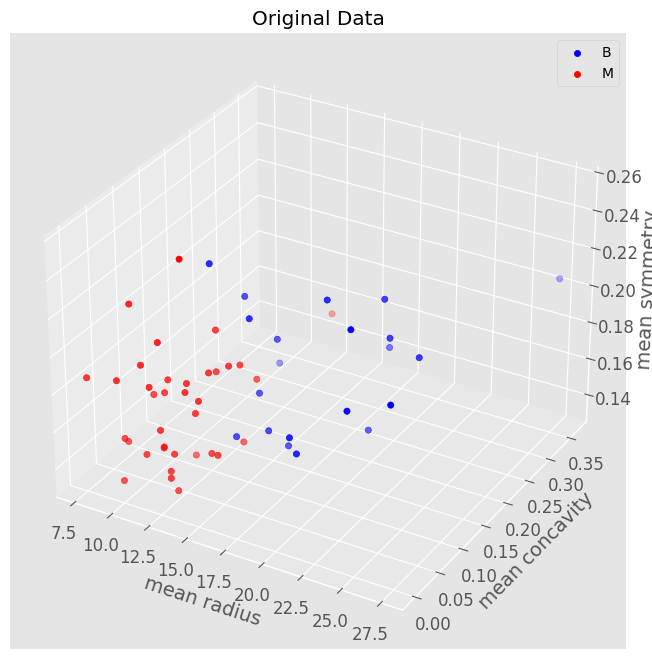

In [7]:
plt_3d_orig(X_test,y_test,feat_name)

Let's visualize the same data reduced into 2D space using PCA:

In [8]:
def plt_2d_pca(X_pca,y):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, aspect='equal')
    ax.scatter(X_pca[y==0, 0], X_pca[y==0, 1], color='b')
    ax.scatter(X_pca[y==1, 0], X_pca[y==1, 1], color='r')
    ax.legend(('B','M'))
    ax.plot([0], [0], "ko")
    ax.arrow(0, 0, 0, 1, head_width=0.05, length_includes_head=True, head_length=0.1, fc='k', ec='k')
    ax.arrow(0, 0, 1, 0, head_width=0.05, length_includes_head=True, head_length=0.1, fc='k', ec='k')
    ax.set_xlabel('$U_1$')
    ax.set_ylabel('$U_2$')
    ax.set_title('2D PCA')
    

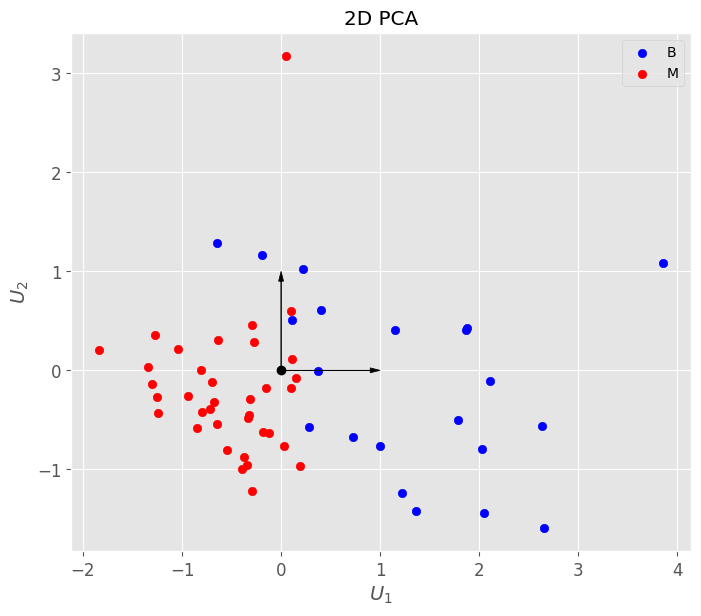

In [9]:
plt_2d_pca(Z_test,y_test)

### Expected output:
<center><img src="outputs/1.PNG" width="480"><center>

Name your reduced test set as `X2D` and use the `inverse_transform` method to reconstruct the data into 3D space. Visulaize the results using `plt_3d_orig_vs_inv_pca` and evaluate the loss of information using `np.allcose()`.

In [10]:
# C2
X2D = Z_test
X3D_inv = pca.inverse_transform(X2D)

In [ ]:
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d

class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        FancyArrowPatch.__init__(self, (0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        FancyArrowPatch.draw(self, renderer)
    
    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        return max(zs)

In [16]:
def plt_3d_orig_vs_inv_pca(X,X2D,X3D_inv,pca,obj):
    x1s = np.linspace(X2D[:,0].min(), X2D[:,0].max(), 10)
    x2s = np.linspace(X2D[:,1].min(), X2D[:,1].max(), 10)
    x1, x2 = np.meshgrid(x1s, x2s)

    U = pca.components_
    R = U.T.dot(U)
    z = (R[0, 2] * x1 + R[1, 2] * x2) / (1 - R[2, 2])
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(x1, x2, z, alpha=0.2, color="k")
    # Plot the principal components as lines instead of arrows
    ax.plot([0, U[0, 0]], [0, U[0, 1]], [0, U[0, 2]], 'g-', linewidth=2)
    ax.plot([0, U[1, 0]], [0, U[1, 1]], [0, U[1, 2]], 'g-', linewidth=2)
    ax.plot([0], [0], [0], "g.")
    ax.plot(X3D_inv[:, 0], X3D_inv[:, 1], X3D_inv[:, 2], "k.")
    ax.plot(X[:, 0], X[:, 1], X[:, 2], "b.")
    ax.set_xlabel("$x_1$", fontsize=18)
    ax.set_ylabel("$x_2$", fontsize=18)
    ax.set_zlabel("$x_3$", fontsize=18)
    ax.view_init(30, 20)
    plt.legend(('Eig. Basis','Rec.','Orig'))

    plt.show()

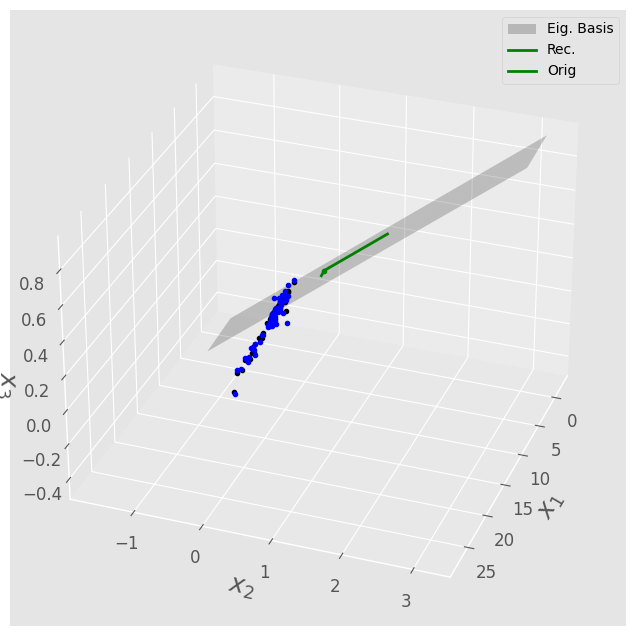

In [17]:
plt_3d_orig_vs_inv_pca(X_test,X2D,X3D_inv,pca,Arrow3D)

### Expected output:
<center><img src="outputs/2.PNG" width="480"><center>

In [18]:
# C3
print('Reconstruction matches original:', np.allclose(X_test, X3D_inv))
print('Mean squared error:', np.mean((X_test - X3D_inv)**2))

Reconstruction matches original: False
Mean squared error: 0.00019945603725372924


---
<span style="color:red">***Question:***</span> *Which of the equations above have you just implemented using `inverse_transform`? What do we need to do in order to improve our results?*

---

Once you answered the second question, implement your answer and repeat all of the above.

In [19]:
# C4
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

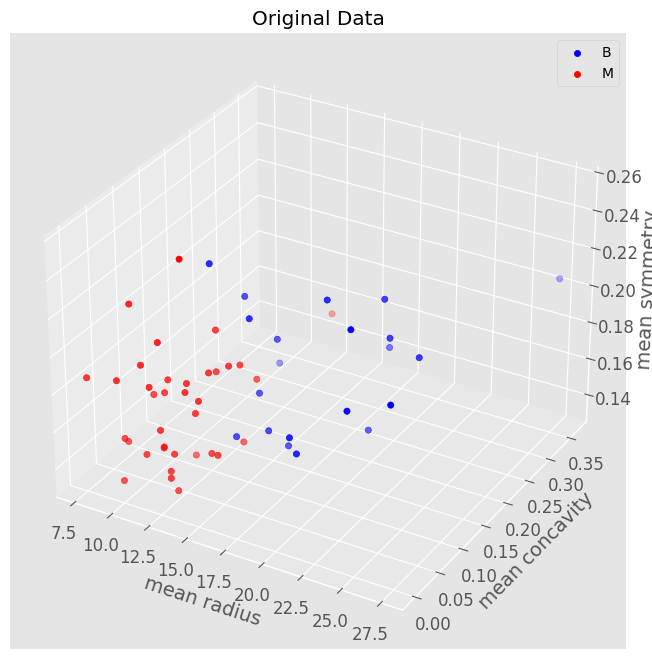

In [20]:
plt_3d_orig(X_test,y_test,feat_name)

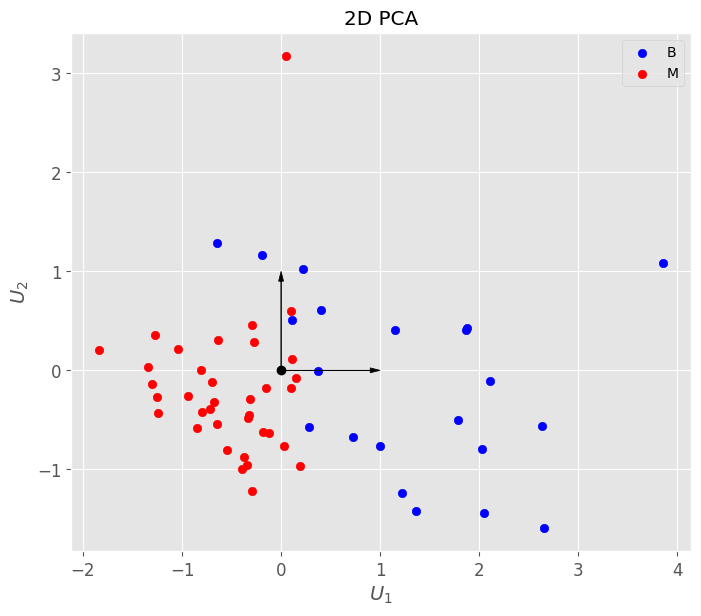

In [21]:
plt_2d_pca(Z_test,y_test)

### Expected output:
<center><img src="outputs/3.PNG" width="480"><center>

In [22]:
# C5
pca = PCA(n_components=n_components, whiten=True)
pca.fit(X_train_scaled)
Z_test = pca.transform(X_test_scaled)
X2D = Z_test
X3D_inv = pca.inverse_transform(X2D)

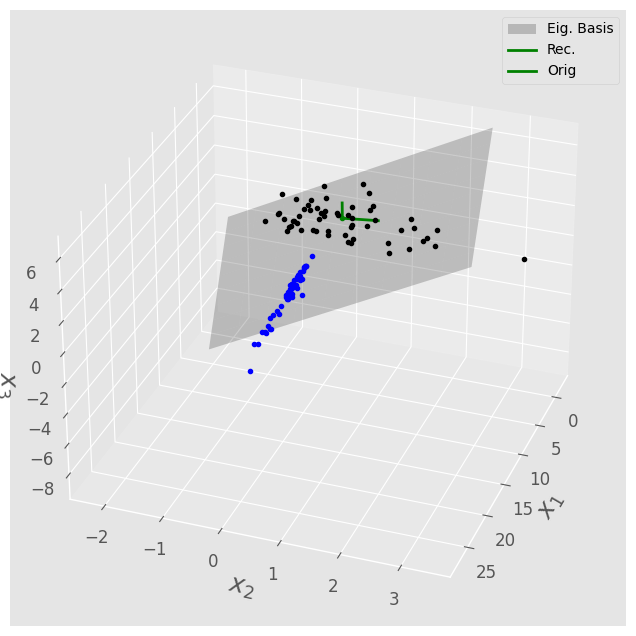

In [23]:
plt_3d_orig_vs_inv_pca(X_test,X2D,X3D_inv,pca,Arrow3D)

### Expected output:
<center><img src="outputs/4.PNG" width="480"><center>

In [24]:
# C6
print('Reconstruction matches original (scaled):', np.allclose(X_test_scaled, X3D_inv))
print('Mean squared error (scaled):', np.mean((X_test_scaled - X3D_inv)**2))

Reconstruction matches original (scaled): False
Mean squared error (scaled): 0.0882841412363727


As we said, we can reduce our data dimensionality as much as we want. Our original data have 30 featurs. Let's scale the data and reduce it to both 2D and 3D.

In [25]:
X = df_feat.values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
# Compute a PCA
n_components = X.shape[1]
pca = PCA(n_components=n_components, whiten=True)

# apply PCA transformation
Z_train = pca.fit_transform(X_train)
Z_test = pca.transform(X_test)

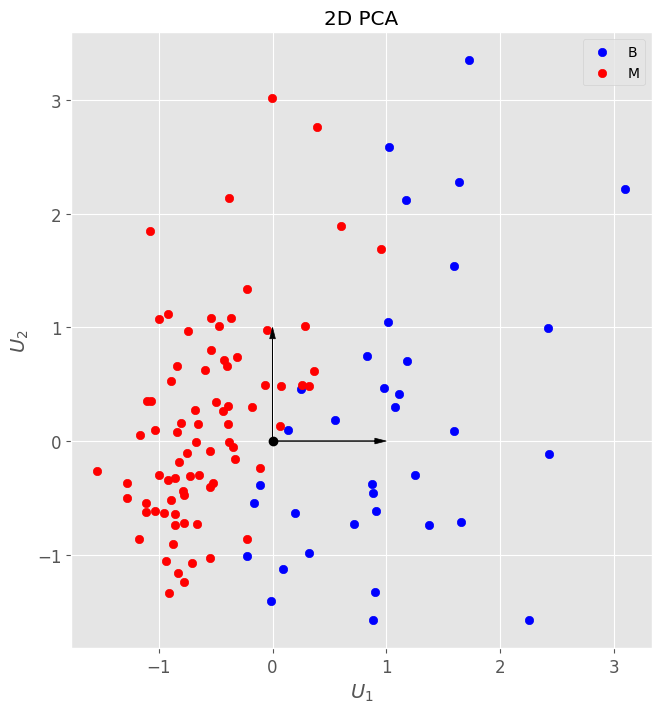

In [27]:
plt_2d_pca(Z_test[:,0:2],y_test)

### Expected output:
<center><img src="outputs/5.PNG" width="480"><center>

In [28]:
def plt_3d_pca(X_pca,y):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca[y==0, 0], X_pca[y==0, 1], X_pca[y==0, 2], color='b');
    ax.scatter(X_pca[y==1, 0], X_pca[y==1, 1], X_pca[y==1, 2], color='r')
    # sns.scatterplot(X_train[:, 0], X_train[:, 1], X_train[:, 2], hue=y_train)
    ax.legend(('B','M'))
    ax.set_title('3D PCA')
    ax.set_xlabel('$U_1$')
    ax.set_ylabel('$U_2$')
    ax.set_zlabel('$U_3$')

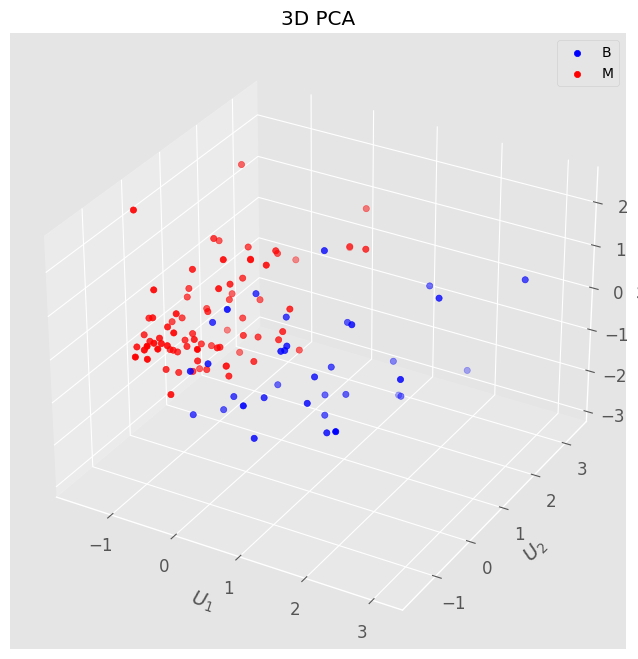

In [29]:
plt_3d_pca(Z_test[:,0:3],y_test)

### Expected output:
<center><img src="outputs/6.PNG" width="480"><center>


---
<span style="color:red">***Question:***</span> *Let's say that we to conserve 95% of the "information" that we have in our data. How do we do that?*

---

Plot a bar plot (using `plt.bar()`) that shows the value of $\lambda$ for every eigenvectors. The eigenvalues are computed within the `PCA` attribute named `explained_variance_`. Calculate the accumelated "energy" conserved for every eignevector using equation (7) and find the number of eigenvectors needed in order to conserve 95% of the information.

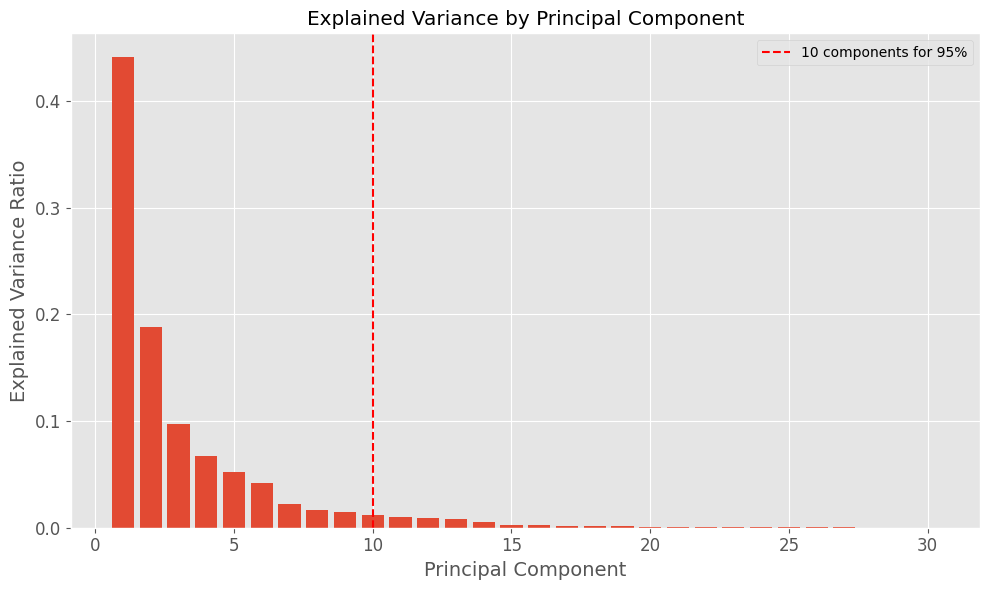

Number of components needed for 95% variance: 10
Total variance explained: 0.9516


In [30]:
# C7
n_components = X.shape[1]
pca = PCA(n_components=n_components, whiten=True)
Z_train = pca.fit_transform(X_train)
Z_test = pca.transform(X_test)

# Calculate explained variance ratio
explained_var_ratio = pca.explained_variance_ratio_
cumsum_var = np.cumsum(explained_var_ratio)

# Find number of components for 95% variance
n_components_95 = np.argmax(cumsum_var >= 0.95) + 1

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(1, len(explained_var_ratio) + 1), explained_var_ratio)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Explained Variance by Principal Component')
ax.axvline(x=n_components_95, color='r', linestyle='--', label=f'{n_components_95} components for 95%')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Number of components needed for 95% variance: {n_components_95}')
print(f'Total variance explained: {cumsum_var[n_components_95-1]:.4f}')

### Expected output:
<center><img src="outputs/7.PNG" width="480"><center>

Fortunately, `scikit-learn` can do this for us automatically once we choose to set a fraction in `n_components` argument and use `explained_variance_ratio_` attribute.

In [31]:
pca = PCA(n_components=0.95)
Z_train = pca.fit_transform(X_train)
Z_test = pca.transform(X_test)
print('{:.2f}% of data information was conserved.'.format(100*np.sum(pca.explained_variance_ratio_)))

95.16% of data information was conserved.


Now let's use PCA as a perprocessing of the classification task. This should help us prevent overfitting and run models faster. Use `PipeLine` and create two pipes: one without PCA and one with PCA (95%). Use the *logistic regression* model and notice the scaling. Compare their scores on the test set.

In [32]:
# C8
X = df_feat.values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
log_reg = LogisticRegression(max_iter=5000)

# Pipeline without PCA
pipe_no_pca = Pipeline(steps=[('scale', StandardScaler()),
                               ('log_reg', LogisticRegression(max_iter=5000))])

# Pipeline with PCA (95%)
pipe_with_pca = Pipeline(steps=[('scale', StandardScaler()),
                                 ('pca', PCA(n_components=0.95)),
                                 ('log_reg', LogisticRegression(max_iter=5000))])

# Train and evaluate
pipe_no_pca.fit(X_train, y_train)
score_no_pca = pipe_no_pca.score(X_test, y_test)

pipe_with_pca.fit(X_train, y_train)
score_with_pca = pipe_with_pca.score(X_test, y_test)

print(f'Score without PCA: {score_no_pca:.4f}')
print(f'Score with PCA (95%): {score_with_pca:.4f}')
print(f'Components used: {pipe_with_pca.named_steps["pca"].n_components_}')

Score without PCA: 0.9737
Score with PCA (95%): 0.9825
Components used: 10


### Expected output:
<center><img src="outputs/8.PNG" width="480"><center>


---
<span style="color:red">***Question:***</span> *Did you get any better results?*

---

Finally, we will see an example of how to apply *kernel PCA* with *rbf* kernel.

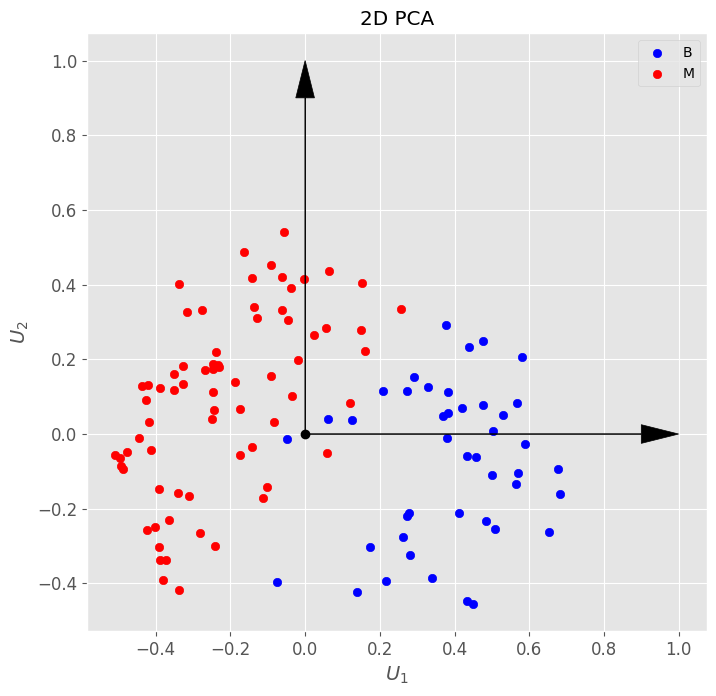

In [33]:
from sklearn.decomposition import KernelPCA
k_pca = KernelPCA(n_components=4, kernel='rbf')
pipe_k_pca = Pipeline(steps=[('scale', StandardScaler()),('k_pca', k_pca)])
pipe_k_pca.fit_transform(X_train)
Z_test = pipe_k_pca.transform(X_test)
plt_2d_pca(Z_test[:,0:2],y_test)

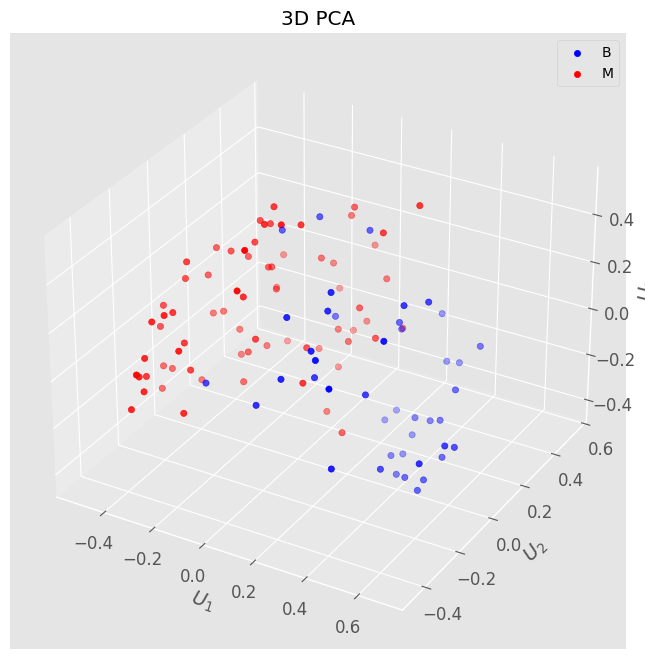

In [34]:
plt_3d_pca(Z_test[:,0:3],y_test)

#### *This tutorial was written by [Moran Davoodi](mailto:morandavoodi@gmail.com) with the assitance of Alon Begin, [Yuval Ben Sason](mailto:yuvalbse@gmail.com) & Kevin Kotzen*